# 2026 NLP Competition Solution

Ноутбук выполняет полный цикл: загрузка данных, EDA, обучение, инференс, постпроцессинг и сохранение `sample_submission.csv`.

In [1]:
import ast
import platform
import random
import re
import warnings
from dataclasses import dataclass
from html import unescape
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from scipy.sparse import hstack
from sklearn.base import clone
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.model_selection import KFold
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import OneHotEncoder
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import AutoModel, AutoModelForSequenceClassification, AutoTokenizer

try:
    from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
except ImportError:
    MultilabelStratifiedKFold = None

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

SEED = 322
TARGET_COLUMNS = ["label_0", "label_1", "label_2", "label_3", "label_4"]


def detect_data_root() -> Path:
    # Local run first.
    local_root = Path(".")
    if (local_root / "train.csv").exists() and (local_root / "test.csv").exists() and (local_root / "sample_submission.csv").exists():
        return local_root

    # Kaggle competition input (folder name can vary by slug).
    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        for train_path in kaggle_input.rglob("train.csv"):
            root = train_path.parent
            if (root / "test.csv").exists() and (root / "sample_submission.csv").exists():
                return root

    raise FileNotFoundError("Could not find train.csv, test.csv, sample_submission.csv")


PROJECT_ROOT = detect_data_root()


@dataclass
class DataBundle:
    train: pd.DataFrame
    test: pd.DataFrame
    sample_submission: pd.DataFrame


def set_global_seed(seed: int = SEED, *, cuda_enabled: bool | None = None) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    use_cuda = torch.cuda.is_available() if cuda_enabled is None else cuda_enabled
    if use_cuda:
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


def parse_target(value: str) -> np.ndarray:
    arr = np.asarray(ast.literal_eval(value), dtype=np.int64)
    if arr.shape != (5,):
        raise ValueError(f"Target must have 5 labels, got {arr.shape}.")
    if not np.isin(arr, [0, 1]).all():
        raise ValueError("Target values must be binary.")
    return arr


def load_competition_data(data_dir: Path | str = ".") -> DataBundle:
    data_dir = Path(data_dir)
    train = pd.read_csv(data_dir / "train.csv", sep="\t")
    test = pd.read_csv(data_dir / "test.csv", sep="\t")
    sample_submission = pd.read_csv(data_dir / "sample_submission.csv")
    return DataBundle(train=train, test=test, sample_submission=sample_submission)


def validate_schema(train: pd.DataFrame, test: pd.DataFrame, sample_submission: pd.DataFrame) -> None:
    if set(train.columns) != {"id", "source", "title", "text", "publication_date", "target"}:
        raise ValueError(f"Unexpected train columns: {train.columns.tolist()}")
    if set(test.columns) != {"id", "source", "title", "text", "publication_date"}:
        raise ValueError(f"Unexpected test columns: {test.columns.tolist()}")
    if set(sample_submission.columns) != {"id", "target"}:
        raise ValueError(f"Unexpected submission columns: {sample_submission.columns.tolist()}")


def add_target_columns(train: pd.DataFrame) -> pd.DataFrame:
    parsed = np.vstack(train["target"].map(parse_target).to_numpy())
    out = train.copy()
    for i, c in enumerate(TARGET_COLUMNS):
        out[c] = parsed[:, i]
    return out


def extract_targets(df: pd.DataFrame) -> np.ndarray:
    return df[TARGET_COLUMNS].to_numpy(dtype=np.int64)


def format_submission_targets(binary_matrix: np.ndarray) -> list[str]:
    return ["[" + ",".join(map(str, row.astype(int).tolist())) + "]" for row in binary_matrix]


def hamming_score(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    # Kaggle score behaves as hamming loss: lower is better.
    return float(np.not_equal(y_true, y_pred).mean())


TAG_RE = re.compile(r"<[^>]+>")
SPACE_RE = re.compile(r"\s+")


def clean_text(value: str) -> str:
    if not isinstance(value, str):
        value = "" if pd.isna(value) else str(value)
    text = unescape(value)
    text = TAG_RE.sub(" ", text)
    text = text.replace("\n", " ").replace("\r", " ").replace("\t", " ")
    return SPACE_RE.sub(" ", text).strip()


def compose_text_features(
    df: pd.DataFrame,
    include_source: bool = True,
    include_date: bool = True,
) -> pd.Series:
    title = df["title"].fillna("").map(clean_text)
    text = df["text"].fillna("").map(clean_text)

    parts = ["[TITLE] " + title, "[TEXT] " + text]

    if include_source:
        source = df["source"].fillna("").astype(str)
        parts.insert(0, "[SRC] " + source)

    if include_date:
        dt = pd.to_datetime(df["publication_date"], errors="coerce")
        year = dt.dt.year.fillna(-1).astype(int).astype(str)
        month = dt.dt.month.fillna(-1).astype(int).astype(str)
        parts.insert(1 if include_source else 0, "[YEAR] " + year + " [MONTH] " + month)

    combined = parts[0]
    for p in parts[1:]:
        combined = combined + " " + p
    return combined


def _mean_pool(last_hidden_state: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    pooled = (last_hidden_state * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)
    return pooled


def build_transformer_embeddings(texts: pd.Series, model_name: str, batch_size: int, max_length: int, cache_path: Path | None = None) -> np.ndarray:
    if cache_path is not None and cache_path.exists():
        return np.load(cache_path)["embeddings"]

    device = TRAINING_DEVICE
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(device)
    model.eval()

    chunks = []
    with torch.inference_mode():
        for start in tqdm(range(0, len(texts), batch_size), desc=f"Embeddings:{model_name}"):
            batch = [f"passage: {t}" for t in texts.iloc[start:start + batch_size].tolist()]
            encoded = tokenizer(batch, padding=True, truncation=True, max_length=max_length, return_tensors="pt").to(device)
            with torch.autocast(device_type="cuda", enabled=(device == "cuda")):
                outputs = model(**encoded)
                pooled = _mean_pool(outputs.last_hidden_state, encoded["attention_mask"])
                pooled = torch.nn.functional.normalize(pooled, p=2, dim=1)
            chunks.append(pooled.float().cpu().numpy())

    embeddings = np.vstack(chunks)
    if cache_path is not None:
        cache_path.parent.mkdir(parents=True, exist_ok=True)
        np.savez_compressed(cache_path, embeddings=embeddings)
    return embeddings


def build_tfidf_features(train_texts: pd.Series, test_texts: pd.Series, max_features_word: int = 120000, max_features_char: int = 80000):
    word = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_df=0.98, sublinear_tf=True, max_features=max_features_word)
    char = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=3, max_df=0.98, sublinear_tf=True, max_features=max_features_char)
    x_train = hstack([word.fit_transform(train_texts), char.fit_transform(train_texts)]).tocsr()
    x_test = hstack([word.transform(test_texts), char.transform(test_texts)]).tocsr()
    return x_train, x_test


def build_disentangled_sparse_features(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    max_title_features: int = 60000,
    max_text_word_features: int = 180000,
    max_text_char_features: int = 90000,
):
    title_train = train_df["title"].fillna("").map(clean_text)
    title_test = test_df["title"].fillna("").map(clean_text)
    text_train = train_df["text"].fillna("").map(clean_text)
    text_test = test_df["text"].fillna("").map(clean_text)

    title_vec = TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.98,
        sublinear_tf=True,
        max_features=max_title_features,
    )
    text_word_vec = TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.98,
        sublinear_tf=True,
        max_features=max_text_word_features,
    )
    text_char_vec = TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 5),
        min_df=3,
        max_df=0.98,
        sublinear_tf=True,
        max_features=max_text_char_features,
    )

    x_title_train = title_vec.fit_transform(title_train)
    x_title_test = title_vec.transform(title_test)
    x_text_word_train = text_word_vec.fit_transform(text_train)
    x_text_word_test = text_word_vec.transform(text_test)
    x_text_char_train = text_char_vec.fit_transform(text_train)
    x_text_char_test = text_char_vec.transform(text_test)

    dt_train = pd.to_datetime(train_df["publication_date"], errors="coerce")
    dt_test = pd.to_datetime(test_df["publication_date"], errors="coerce")

    cat_train = pd.DataFrame(
        {
            "source": train_df["source"].fillna("unknown").astype(str),
            "month": dt_train.dt.month.fillna(-1).astype(int).astype(str),
            "year": dt_train.dt.year.fillna(-1).astype(int).astype(str),
        }
    )
    cat_test = pd.DataFrame(
        {
            "source": test_df["source"].fillna("unknown").astype(str),
            "month": dt_test.dt.month.fillna(-1).astype(int).astype(str),
            "year": dt_test.dt.year.fillna(-1).astype(int).astype(str),
        }
    )

    try:
        cat_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        cat_encoder = OneHotEncoder(handle_unknown="ignore", sparse=True)

    x_cat_train = cat_encoder.fit_transform(cat_train)
    x_cat_test = cat_encoder.transform(cat_test)

    x_train = hstack(
        [x_title_train, x_text_word_train, x_text_char_train, x_cat_train],
        format="csr",
    )
    x_test = hstack(
        [x_title_test, x_text_word_test, x_text_char_test, x_cat_test],
        format="csr",
    )

    return x_train, x_test


def build_base_classifier(seed: int = SEED, C: float = 2.0, class_weight: str | None = "balanced"):
    base = LogisticRegression(
        C=C,
        max_iter=600,
        solver="liblinear",
        random_state=seed,
        class_weight=class_weight,
    )
    return OneVsRestClassifier(base)


def build_sgd_classifier(seed: int = SEED, alpha: float = 3e-5, class_weight: str | None = "balanced"):
    base = SGDClassifier(
        loss="log_loss",
        penalty="l2",
        alpha=alpha,
        max_iter=3000,
        tol=1e-3,
        random_state=seed,
        class_weight=class_weight,
    )
    return OneVsRestClassifier(base)


def make_multilabel_splitter(n_splits: int = 5, seed: int = SEED):
    if MultilabelStratifiedKFold is not None:
        return MultilabelStratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    return KFold(n_splits=n_splits, shuffle=True, random_state=seed)


def make_time_splits(df: pd.DataFrame, n_splits: int = 5, min_train_folds: int = 1):
    """Forward-chaining time split: train uses only past, valid uses next block."""
    dt = pd.to_datetime(df["publication_date"], errors="coerce")
    dt = dt.fillna(pd.Timestamp("1970-01-01"))
    order = np.argsort(dt.to_numpy())
    fold_bins = np.array_split(order, n_splits)

    splits = []
    for i in range(max(min_train_folds, 1), n_splits):
        va_idx = fold_bins[i]
        tr_idx = np.concatenate(fold_bins[:i])
        if len(tr_idx) == 0 or len(va_idx) == 0:
            continue
        splits.append((tr_idx, va_idx))

    if not splits:
        # Fallback to a single split if data is too small.
        cut = max(1, len(order) // 2)
        splits = [(order[:cut], order[cut:])]

    return splits


def fit_cv_models(x, y: np.ndarray, estimator, splitter, score_fn):
    oof = np.zeros((y.shape[0], y.shape[1]), dtype=np.float32)
    oof_mask = np.zeros(y.shape[0], dtype=bool)
    models, fold_scores = [], []

    if hasattr(splitter, "split"):
        split_iter = splitter.split(x, y)
    else:
        split_iter = splitter

    for fold_idx, (tr_idx, va_idx) in enumerate(split_iter, start=1):
        model = clone(estimator)
        model.fit(x[tr_idx], y[tr_idx])
        proba = model.predict_proba(x[va_idx])
        oof[va_idx] = proba
        oof_mask[va_idx] = True
        pred = (proba >= 0.5).astype(np.int64)
        score = score_fn(y[va_idx], pred)
        fold_scores.append(float(score))
        models.append(model)
        print(f"Fold {fold_idx}: hamming_loss={score:.6f}")
    return {"oof_proba": oof, "oof_mask": oof_mask, "models": models, "fold_scores": fold_scores}


def fit_full_model(x, y: np.ndarray, estimator):
    model = clone(estimator)
    model.fit(x, y)
    return model


def find_best_thresholds(y_true: np.ndarray, y_proba: np.ndarray, score_fn, grid: np.ndarray | None = None):
    if grid is None:
        grid = np.linspace(0.02, 0.98, 97)
    thresholds = np.full(y_true.shape[1], 0.5, dtype=np.float32)
    best_global = score_fn(y_true, (y_proba >= thresholds).astype(np.int64))
    for label in range(y_true.shape[1]):
        best_t, best_score = thresholds[label], best_global
        for t in grid:
            trial = thresholds.copy()
            trial[label] = float(t)
            score = score_fn(y_true, (y_proba >= trial).astype(np.int64))
            if score < best_score:
                best_t, best_score = float(t), score
        thresholds[label] = best_t
        best_global = best_score
    return thresholds, float(best_global)


def apply_thresholds(y_proba: np.ndarray, thresholds: np.ndarray) -> np.ndarray:
    return (y_proba >= thresholds).astype(np.int64)


class TextDataset(Dataset):
    def __init__(self, texts: list[str], targets: np.ndarray | None = None):
        self.texts = texts
        self.targets = targets

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        item = {"text": self.texts[idx]}
        if self.targets is not None:
            item["targets"] = self.targets[idx].astype(np.float32)
        return item


def collate_fn_builder(tokenizer, max_length: int):
    def collate_fn(batch):
        texts = [x["text"] for x in batch]
        encoded = tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        )
        if "targets" in batch[0]:
            targets = torch.tensor([x["targets"] for x in batch], dtype=torch.float32)
            encoded["labels"] = targets
        return encoded

    return collate_fn


def resolve_training_device() -> str:
    """Use CUDA only if kernels transformers rely on (e.g. torch.arange on GPU) actually run."""
    if not torch.cuda.is_available():
        return "cpu"
    try:
        dev = torch.device("cuda")
        _ = torch.arange(128, device=dev, dtype=torch.long)
        x = torch.zeros(4, 32, dtype=torch.long, device=dev)
        emb = torch.nn.Embedding(512, 32).to(dev)
        _ = emb(x)
        torch.cuda.synchronize()
        del emb, x
        torch.cuda.empty_cache()
        return "cuda"
    except Exception as exc:
        msg = str(exc).split("\n")[0][:240]
        print(f"CUDA smoke test failed ({msg}); using CPU.")
        return "cpu"


def predict_proba_model(model, loader, device: str) -> np.ndarray:
    model.eval()
    probs = []
    with torch.no_grad():
        for batch in loader:
            labels = batch.pop("labels", None)
            batch = {k: v.to(device) for k, v in batch.items()}
            logits = model(**batch).logits
            p = torch.sigmoid(logits).cpu().numpy()
            probs.append(p)
    return np.vstack(probs)


def train_one_fold_transformer(
    train_texts: list[str],
    train_targets: np.ndarray,
    val_texts: list[str],
    model_name: str,
    seed: int,
    epochs: int,
    lr: float,
    batch_size: int,
    max_length: int,
) -> tuple[np.ndarray, AutoModelForSequenceClassification, AutoTokenizer]:
    set_global_seed(seed, cuda_enabled=(TRAINING_DEVICE == "cuda"))
    device = TRAINING_DEVICE
    eff_bs = batch_size if device == "cuda" else min(batch_size, 8)

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=train_targets.shape[1],
        problem_type="multi_label_classification",
    ).to(device)

    train_ds = TextDataset(train_texts, train_targets)
    val_ds = TextDataset(val_texts, None)

    collate_fn = collate_fn_builder(tokenizer, max_length=max_length)
    train_loader = DataLoader(train_ds, batch_size=eff_bs, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_ds, batch_size=eff_bs * 2, shuffle=False, collate_fn=collate_fn)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    model.train()
    for epoch in range(epochs):
        epoch_losses = []
        for batch in train_loader:
            labels = batch.pop("labels").to(device)
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch, labels=labels)
            loss = outputs.loss
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_losses.append(loss.item())
        print(f"Epoch {epoch + 1}/{epochs} loss={np.mean(epoch_losses):.6f}")

    val_proba = predict_proba_model(model, val_loader, device=device)
    return val_proba, model, tokenizer


def calibrate_with_logreg(y_true: np.ndarray, y_proba: np.ndarray, y_test_proba: np.ndarray, seed: int = SEED):
    # GO component: classical model over probability features (neural and/or stacked).
    meta = OneVsRestClassifier(
        LogisticRegression(
            C=6.0,
            solver="liblinear",
            max_iter=1200,
            random_state=seed,
        )
    )
    meta.fit(y_proba, y_true)
    calibrated_train = meta.predict_proba(y_proba)
    calibrated_test = meta.predict_proba(y_test_proba)
    return calibrated_train, calibrated_test


def predict_test_from_cv_models(models, x_test) -> np.ndarray:
    probs = [m.predict_proba(x_test) for m in models]
    return np.mean(probs, axis=0).astype(np.float32)


def search_alpha_blend(
    y_true: np.ndarray,
    oof_a: np.ndarray,
    oof_b: np.ndarray,
    score_fn,
    alphas: np.ndarray | None = None,
):
    if alphas is None:
        alphas = np.linspace(0.0, 1.0, 21)
    best_alpha, best_loss = 0.5, score_fn(y_true, (oof_a >= 0.5).astype(np.int64))
    for alpha in alphas:
        blend = alpha * oof_a + (1.0 - alpha) * oof_b
        loss = score_fn(y_true, (blend >= 0.5).astype(np.int64))
        if loss < best_loss:
            best_alpha, best_loss = float(alpha), loss
    return best_alpha, float(best_loss)


TRAINING_DEVICE = resolve_training_device()
print(f"Training device: {TRAINING_DEVICE}")
set_global_seed(SEED, cuda_enabled=(TRAINING_DEVICE == "cuda"))
print(f"Seed fixed to: {SEED}")
print(f"Python: {platform.python_version()}")

Training device: cuda
Seed fixed to: 322
Python: 3.12.12


In [2]:
bundle = load_competition_data(PROJECT_ROOT)
train_df = bundle.train
test_df = bundle.test
sample_submission = bundle.sample_submission

validate_schema(train_df, test_df, sample_submission)
train_df = add_target_columns(train_df)

print("Data root:", PROJECT_ROOT)
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Sample submission shape:", sample_submission.shape)
display(train_df.head(2))

Data root: /kaggle/input/competitions/2026-nlp
Train shape: (16701, 11)
Test shape: (4969, 5)
Sample submission shape: (4969, 2)


,id,source,title,text,publication_date,target,label_0,label_1,label_2,label_3,label_4
0,0,Novosti,Рейтинг регионов по уровню закредитованности н...,Средний <content>уровень</content> <source>ria...,2019-12-23 00:00,"[0, 1, 0, 0, 0]",0,1,0,0,0
1,1,Novosti,Названы самые закредитованные российские регионы,"МОСКВА, 23 дек — РИА Новости. Наиболее закре...",2019-12-23 00:21,"[0, 1, 0, 0, 0]",0,1,0,0,0


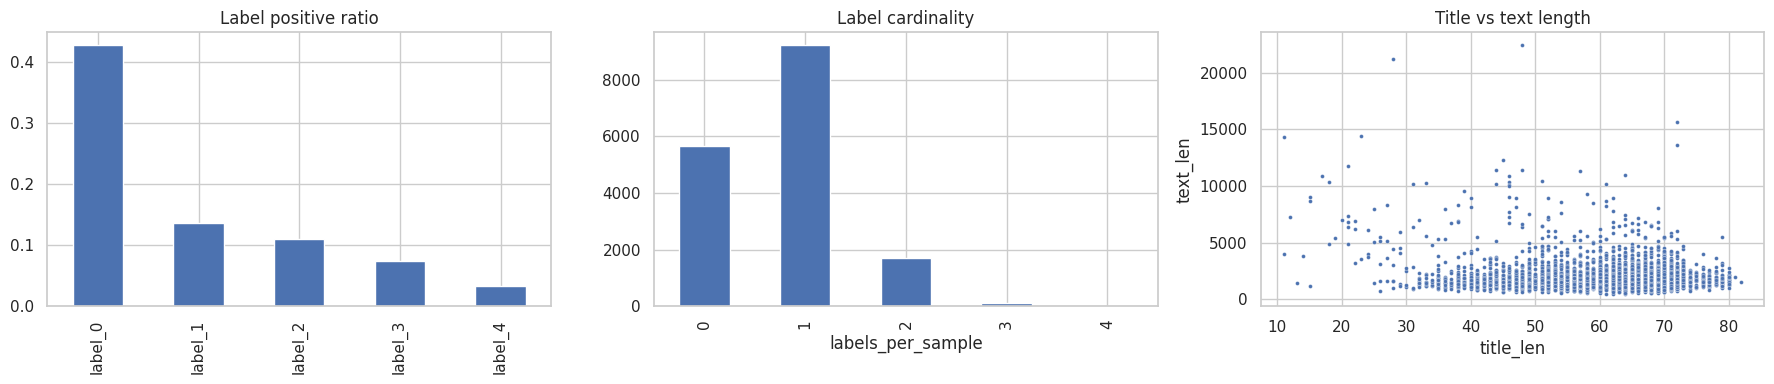

,positive_ratio
label_0,0.427819
label_1,0.136279
label_2,0.109934
label_3,0.074427
label_4,0.032573


,count
source,
Novosti,12759
Svezhesti,3942


In [3]:
# EDA
y = extract_targets(train_df)
label_freq = pd.Series(y.mean(axis=0), index=TARGET_COLUMNS, name="positive_ratio")
cardinality = pd.Series(y.sum(axis=1), name="labels_per_sample")

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
label_freq.plot(kind="bar", ax=axes[0], title="Label positive ratio")
cardinality.value_counts().sort_index().plot(kind="bar", ax=axes[1], title="Label cardinality")

tmp = train_df.copy()
tmp["title_len"] = tmp["title"].fillna("").astype(str).str.len()
tmp["text_len"] = tmp["text"].fillna("").astype(str).str.len()
sns.scatterplot(data=tmp.sample(min(4000, len(tmp)), random_state=SEED), x="title_len", y="text_len", s=8, ax=axes[2])
axes[2].set_title("Title vs text length")
plt.tight_layout()
plt.show()

display(label_freq.to_frame())
display(train_df["source"].value_counts().head(20).to_frame("count"))

In [4]:
# v1.1 feature recipes: neural (rich) + TF-IDF (title_text, best classical LB)
best_variant_name = "title_text_source_date"
tfidf_variant_name = "title_text"

train_texts = compose_text_features(train_df, include_source=True, include_date=True)
test_texts = compose_text_features(test_df, include_source=True, include_date=True)

print("Selected feature recipe:", best_variant_name)
display(train_texts.head(2))

Selected feature recipe: title_text_source_date


0    [SRC] Novosti [YEAR] 2019 [MONTH] 12 [TITLE] Р...
1    [SRC] Novosti [YEAR] 2019 [MONTH] 12 [TITLE] Н...
dtype: object

In [5]:
# v1.2 training config (hybrid + optional rubert-base)
if str(PROJECT_ROOT).startswith("/kaggle/input"):
    ARTIFACTS_DIR = Path("/kaggle/working/artifacts")
else:
    ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

RUN_MODE = "full"  # debug: 1 epoch, 1 seed, 3 folds | full: production
MODEL_PROFILE = "tiny"  # tiny | base (switch to base to chase 0.03560)
MODEL_OPTIONS = {
    "tiny": "cointegrated/rubert-tiny2",
    "base": "DeepPavlov/rubert-base-cased",
}
MODEL_NAME = MODEL_OPTIONS[MODEL_PROFILE]
ENABLE_HYBRID = True
ENABLE_NEURAL = True  # False: skip transformer (~15 min), TF-IDF + GO only
TFIDF_LR_SGD_BLEND = True  # LR + SGD ensemble per seed (v1.2)
ENABLE_FINAL_REFIT = RUN_MODE == "full"

MAX_LENGTH = 256
LR = 2e-5
if RUN_MODE == "full":
    N_SPLITS = 5
    ENSEMBLE_SEEDS = [322, 42, 2026]
    if MODEL_PROFILE == "base":
        TRAIN_EPOCHS = 3
        BATCH_SIZE = 16
    else:
        TRAIN_EPOCHS = 2
        BATCH_SIZE = 24
else:
    N_SPLITS = 3
    ENSEMBLE_SEEDS = [322]
    TRAIN_EPOCHS = 1
    BATCH_SIZE = 16

if TRAINING_DEVICE == "cpu":
    BATCH_SIZE = min(BATCH_SIZE, 8)

if Path("/kaggle").exists() and TRAINING_DEVICE == "cpu" and RUN_MODE == "full":
    raise RuntimeError(
        "Kaggle GPU required for RUN_MODE=full. Set Accelerator to GPU T4 x2 and re-run."
    )

print("Model profile:", MODEL_PROFILE)
print("Model:", MODEL_NAME)
print("Run mode:", RUN_MODE)
print("Hybrid:", ENABLE_HYBRID, "| Neural:", ENABLE_NEURAL, "| TF-IDF LR+SGD:", TFIDF_LR_SGD_BLEND)
print("Final refit:", ENABLE_FINAL_REFIT)
print("Training device:", TRAINING_DEVICE)
print("Epochs:", TRAIN_EPOCHS, "Batch:", BATCH_SIZE, "LR:", LR)
print("CV folds:", N_SPLITS, "Seeds:", ENSEMBLE_SEEDS)

Model profile: tiny
Model: cointegrated/rubert-tiny2
Run mode: full
Hybrid: True | Neural: True | TF-IDF LR+SGD: True
Final refit: True
Training device: cuda
Epochs: 2 Batch: 24 LR: 2e-05
CV folds: 5 Seeds: [322, 42, 2026]


In [6]:
# Build forward time splits once for all CV branches
CV_STRATEGY = "forward_time"
time_splits = make_time_splits(train_df, n_splits=N_SPLITS, min_train_folds=1)
cv_mask = np.zeros(len(train_df), dtype=bool)
for _, va_idx in time_splits:
    cv_mask[va_idx] = True

print("CV strategy:", CV_STRATEGY)
print("Forward folds:", len(time_splits))
print("CV masked rows:", int(cv_mask.sum()), "/", len(cv_mask))

CV strategy: forward_time
Forward folds: 4
CV masked rows: 13360 / 16701


In [7]:
# Neural CV training (forward_time)
y = extract_targets(train_df)
train_text_list = train_texts.tolist()
test_text_list = test_texts.tolist()

n_samples = len(train_df)
n_labels = y.shape[1]
seed_oof_list = []
seed_test_list = []
seed_losses = []

if not ENABLE_NEURAL:
    print("Skipping neural training (ENABLE_NEURAL=False)")
    cv_oof_neural = np.full((n_samples, n_labels), 0.5, dtype=np.float32)
    test_proba_neural = np.full((len(test_df), n_labels), 0.5, dtype=np.float32)
else:
    for seed_value in ENSEMBLE_SEEDS:
        print(f"\n=== Seed {seed_value} ===")
        oof_seed = np.zeros((n_samples, n_labels), dtype=np.float32)
        test_fold_probs = []

        for fold_idx, (tr_idx, va_idx) in enumerate(time_splits, start=1):
            print(f"Fold {fold_idx}/{len(time_splits)} train={len(tr_idx)} valid={len(va_idx)}")

            val_proba, model, tokenizer = train_one_fold_transformer(
                train_texts=[train_text_list[i] for i in tr_idx],
                train_targets=y[tr_idx],
                val_texts=[train_text_list[i] for i in va_idx],
                model_name=MODEL_NAME,
                seed=seed_value,
                epochs=TRAIN_EPOCHS,
                lr=LR,
                batch_size=BATCH_SIZE,
                max_length=MAX_LENGTH,
            )

            oof_seed[va_idx] = val_proba

            test_loader = DataLoader(
                TextDataset(test_text_list, None),
                batch_size=BATCH_SIZE * 2,
                shuffle=False,
                collate_fn=collate_fn_builder(tokenizer, max_length=MAX_LENGTH),
            )
            fold_test_proba = predict_proba_model(model, test_loader, device=TRAINING_DEVICE)
            test_fold_probs.append(fold_test_proba)

            del model
            if TRAINING_DEVICE == "cuda":
                torch.cuda.empty_cache()

        seed_test_mean = np.mean(test_fold_probs, axis=0)
        seed_oof_list.append(oof_seed)
        seed_test_list.append(seed_test_mean)

        pred_seed = (oof_seed[cv_mask] >= 0.5).astype(np.int64)
        loss_seed = hamming_score(y[cv_mask], pred_seed)
        seed_losses.append(loss_seed)
        print(f"OOF neural seed={seed_value} hamming_loss@0.5 (masked): {loss_seed:.6f}")

    cv_oof_neural = np.mean(seed_oof_list, axis=0)
    test_proba_neural = np.mean(seed_test_list, axis=0)

    neural_pred = (cv_oof_neural[cv_mask] >= 0.5).astype(np.int64)
    neural_loss = hamming_score(y[cv_mask], neural_pred)
    print(f"OOF neural ensemble hamming_loss@0.5 (masked): {neural_loss:.6f}")


=== Seed 322 ===
Fold 1/4 train=3341 valid=3340


config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider trai

Epoch 1/2 loss=0.364259
Epoch 2/2 loss=0.209359
Fold 4/4 train=13361 valid=3340


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider trai

Epoch 1/2 loss=0.334553
Epoch 2/2 loss=0.189514
OOF neural seed=2026 hamming_loss@0.5 (masked): 0.072410
OOF neural ensemble hamming_loss@0.5 (masked): 0.073069


In [8]:
# TF-IDF branch (forward_time CV) — v1.2 LR + optional SGD blend per seed
train_texts_tfidf = compose_text_features(train_df, include_source=False, include_date=False)
test_texts_tfidf = compose_text_features(test_df, include_source=False, include_date=False)
x_train_tfidf, x_test_tfidf = build_tfidf_features(train_texts_tfidf, test_texts_tfidf)

tfidf_seed_oof_list = []
tfidf_seed_test_list = []
tfidf_seed_losses = []
tfidf_lr_blend_weights = []

if ENABLE_HYBRID:
    print(f"\n=== TF-IDF branch ({tfidf_variant_name}) ===")
    for seed_value in ENSEMBLE_SEEDS:
        est_lr = build_base_classifier(seed=seed_value, C=2.0)
        cv_lr = fit_cv_models(x_train_tfidf, y, est_lr, time_splits, hamming_score)

        if TFIDF_LR_SGD_BLEND:
            est_sgd = build_sgd_classifier(seed=seed_value)
            cv_sgd = fit_cv_models(x_train_tfidf, y, est_sgd, time_splits, hamming_score)
            w_lr, _ = search_alpha_blend(
                y[cv_mask],
                cv_lr["oof_proba"][cv_mask],
                cv_sgd["oof_proba"][cv_mask],
                hamming_score,
            )
            tfidf_lr_blend_weights.append(w_lr)
            oof_seed = (w_lr * cv_lr["oof_proba"] + (1.0 - w_lr) * cv_sgd["oof_proba"]).astype(np.float32)
            if ENABLE_FINAL_REFIT:
                full_lr = fit_full_model(x_train_tfidf, y, est_lr)
                full_sgd = fit_full_model(x_train_tfidf, y, est_sgd)
                test_lr = full_lr.predict_proba(x_test_tfidf)
                test_sgd = full_sgd.predict_proba(x_test_tfidf)
                test_seed = (w_lr * test_lr + (1.0 - w_lr) * test_sgd).astype(np.float32)
            else:
                test_lr = predict_test_from_cv_models(cv_lr["models"], x_test_tfidf)
                test_sgd = predict_test_from_cv_models(cv_sgd["models"], x_test_tfidf)
                test_seed = (w_lr * test_lr + (1.0 - w_lr) * test_sgd).astype(np.float32)
            print(f"  seed={seed_value} LR blend weight: {w_lr:.2f}")
        else:
            oof_seed = cv_lr["oof_proba"]
            if ENABLE_FINAL_REFIT:
                test_seed = fit_full_model(x_train_tfidf, y, est_lr).predict_proba(x_test_tfidf).astype(np.float32)
            else:
                test_seed = predict_test_from_cv_models(cv_lr["models"], x_test_tfidf)

        tfidf_seed_oof_list.append(oof_seed)
        tfidf_seed_test_list.append(test_seed)

        pred_tfidf = (oof_seed[cv_mask] >= 0.5).astype(np.int64)
        loss_tfidf = hamming_score(y[cv_mask], pred_tfidf)
        tfidf_seed_losses.append(loss_tfidf)
        print(f"OOF TF-IDF seed={seed_value} hamming_loss@0.5 (masked): {loss_tfidf:.6f}")

    cv_oof_tfidf = np.mean(tfidf_seed_oof_list, axis=0)
    test_proba_tfidf = np.mean(tfidf_seed_test_list, axis=0)

    tfidf_pred = (cv_oof_tfidf[cv_mask] >= 0.5).astype(np.int64)
    tfidf_loss = hamming_score(y[cv_mask], tfidf_pred)
    print(f"OOF TF-IDF ensemble hamming_loss@0.5 (masked): {tfidf_loss:.6f}")
else:
    cv_oof_tfidf = cv_oof_neural.copy()
    test_proba_tfidf = test_proba_neural.copy()
    tfidf_seed_losses = []
    tfidf_lr_blend_weights = []
    print("Hybrid disabled — neural-only probabilities will be used.")


=== TF-IDF branch (title_text) ===
Fold 1: hamming_loss=0.054850
Fold 2: hamming_loss=0.056946
Fold 3: hamming_loss=0.054850
Fold 4: hamming_loss=0.053653
Fold 1: hamming_loss=0.055329
Fold 2: hamming_loss=0.053952
Fold 3: hamming_loss=0.054491
Fold 4: hamming_loss=0.052934
  seed=322 LR blend weight: 0.05
OOF TF-IDF seed=322 hamming_loss@0.5 (masked): 0.054147
Fold 1: hamming_loss=0.054850
Fold 2: hamming_loss=0.056946
Fold 3: hamming_loss=0.054850
Fold 4: hamming_loss=0.053653
Fold 1: hamming_loss=0.054371
Fold 2: hamming_loss=0.055868
Fold 3: hamming_loss=0.053593
Fold 4: hamming_loss=0.053234
  seed=42 LR blend weight: 0.20
OOF TF-IDF seed=42 hamming_loss@0.5 (masked): 0.054132
Fold 1: hamming_loss=0.054850
Fold 2: hamming_loss=0.056946
Fold 3: hamming_loss=0.054850
Fold 4: hamming_loss=0.053653
Fold 1: hamming_loss=0.054671
Fold 2: hamming_loss=0.053593
Fold 3: hamming_loss=0.054970
Fold 4: hamming_loss=0.052754
  seed=2026 LR blend weight: 0.05
OOF TF-IDF seed=2026 hamming_loss@

In [9]:
# v1.1 hybrid: alpha blend + GO stack (pick best on masked OOF)
y_mask = y[cv_mask]
oof_nn = cv_oof_neural[cv_mask]
oof_tf = cv_oof_tfidf[cv_mask]

if ENABLE_HYBRID:
    HYBRID_ALPHA, blend_loss_at05 = search_alpha_blend(
        y_mask, oof_tf, oof_nn, hamming_score
    )
    print(f"Best hybrid alpha (TF-IDF weight): {HYBRID_ALPHA:.2f} | loss@0.5: {blend_loss_at05:.6f}")

    oof_alpha = HYBRID_ALPHA * cv_oof_tfidf + (1.0 - HYBRID_ALPHA) * cv_oof_neural
    test_alpha = HYBRID_ALPHA * test_proba_tfidf + (1.0 - HYBRID_ALPHA) * test_proba_neural

    stack_train = np.hstack([oof_tf, oof_nn]).astype(np.float32)
    stack_test = np.hstack([test_proba_tfidf, test_proba_neural]).astype(np.float32)
    oof_go, test_go = calibrate_with_logreg(y_mask, stack_train, stack_test, seed=SEED)

    loss_alpha = hamming_score(y_mask, (oof_alpha[cv_mask] >= 0.5).astype(np.int64))
    loss_go = hamming_score(y_mask, (oof_go >= 0.5).astype(np.int64))
    print(f"OOF alpha-blend hamming_loss@0.5 (masked): {loss_alpha:.6f}")
    print(f"OOF GO-stack hamming_loss@0.5 (masked): {loss_go:.6f}")

    if loss_go <= loss_alpha:
        SELECTED_HEAD = "GO_stack"
        cv_oof_proba = np.zeros_like(cv_oof_neural)
        cv_oof_proba[cv_mask] = oof_go
        test_proba_final = test_go.astype(np.float32)
        baseline_score = loss_go
    else:
        SELECTED_HEAD = "alpha_blend"
        cv_oof_proba = oof_alpha
        test_proba_final = test_alpha.astype(np.float32)
        baseline_score = loss_alpha
else:
    SELECTED_HEAD = "neural_only"
    cv_oof_go, test_go = calibrate_with_logreg(y_mask, oof_nn, test_proba_neural, seed=SEED)
    cv_oof_proba = np.zeros_like(cv_oof_neural)
    cv_oof_proba[cv_mask] = cv_oof_go
    test_proba_final = test_go.astype(np.float32)
    baseline_score = hamming_score(y_mask, (cv_oof_go >= 0.5).astype(np.int64))
    print(f"OOF neural GO hamming_loss@0.5 (masked): {baseline_score:.6f}")

print(f"Selected head: {SELECTED_HEAD}")
print(f"Selected OOF hamming_loss@0.5: {baseline_score:.6f}")

Best hybrid alpha (TF-IDF weight): 0.70 | loss@0.5: 0.051287
OOF alpha-blend hamming_loss@0.5 (masked): 0.051287
OOF GO-stack hamming_loss@0.5 (masked): 0.050584
Selected head: GO_stack
Selected OOF hamming_loss@0.5: 0.050584


In [10]:
# Threshold tuning on selected OOF probabilities (blended if available)
best_thresholds, tuned_score = find_best_thresholds(
    y_true=y[cv_mask],
    y_proba=cv_oof_proba[cv_mask],
    score_fn=hamming_score,
)
print("Best thresholds:", best_thresholds)
print(f"Tuned OOF hamming_loss (masked): {tuned_score:.6f}")

Best thresholds: [0.47 0.48 0.54 0.46 0.36]
Tuned OOF hamming_loss (masked): 0.049910


In [11]:
# Submission from hybrid / GO probabilities
test_pred = apply_thresholds(test_proba_final, best_thresholds)

submission = sample_submission.copy()
submission["id"] = test_df["id"].values
submission["target"] = format_submission_targets(test_pred)

if str(PROJECT_ROOT).startswith("/kaggle/input"):
    output_path = Path("/kaggle/working/sample_submission.csv")
else:
    output_path = PROJECT_ROOT / "sample_submission.csv"

submission.to_csv(output_path, index=False)
print("Saved submission:", output_path)
display(submission.head())

Saved submission: /kaggle/working/sample_submission.csv


,id,target
0,16701,"[0,0,0,0,0]"
1,16702,"[0,0,0,0,0]"
2,16703,"[0,0,1,0,0]"
3,16704,"[0,0,0,0,0]"
4,16705,"[0,0,0,0,0]"


In [12]:
print("=== Reproducibility report ===")
print("Seed:", SEED)
print("Training device:", TRAINING_DEVICE)
print("Model profile:", MODEL_PROFILE, "| Model:", MODEL_NAME)
print("CV strategy:", CV_STRATEGY)
print("Ensemble seeds:", ENSEMBLE_SEEDS)
print("Epochs:", TRAIN_EPOCHS, "Batch:", BATCH_SIZE, "LR:", LR)
print("Hybrid:", ENABLE_HYBRID, "| Selected head:", SELECTED_HEAD)
print("Neural seed losses@0.5:", [round(v, 6) for v in seed_losses])
if ENABLE_HYBRID:
    print("TF-IDF seed losses@0.5:", [round(v, 6) for v in tfidf_seed_losses])
    if TFIDF_LR_SGD_BLEND and tfidf_lr_blend_weights:
        print("TF-IDF LR blend weights:", [round(v, 2) for v in tfidf_lr_blend_weights])
    if SELECTED_HEAD in {"alpha_blend", "GO_stack"}:
        print("Hybrid alpha (TF-IDF weight):", round(HYBRID_ALPHA, 4))
print("Neural text:", best_variant_name, "| TF-IDF text:", tfidf_variant_name)
print("OOF selected loss@0.5:", round(baseline_score, 6))
print("OOF tuned loss:", round(tuned_score, 6))
print("OOF coverage:", int(cv_mask.sum()), "/", len(cv_mask))
print("Train rows:", len(train_df), "| Test rows:", len(test_df))

=== Reproducibility report ===
Seed: 322
Training device: cuda
Model profile: tiny | Model: cointegrated/rubert-tiny2
CV strategy: forward_time
Ensemble seeds: [322, 42, 2026]
Epochs: 2 Batch: 24 LR: 2e-05
Hybrid: True | Selected head: GO_stack
Neural seed losses@0.5: [0.07488, 0.075704, 0.07241]
TF-IDF seed losses@0.5: [0.054147, 0.054132, 0.053877]
TF-IDF LR blend weights: [0.05, 0.2, 0.05]
Hybrid alpha (TF-IDF weight): 0.7
Neural text: title_text_source_date | TF-IDF text: title_text
OOF selected loss@0.5: 0.050584
OOF tuned loss: 0.04991
OOF coverage: 13360 / 16701
Train rows: 16701 | Test rows: 4969
